In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data = {
    "study_hours": [2, 3, 4, 5, 6, 7, 8, 2.5, 4.5, 6.5,
                    3.5, 5.5, 7.5, 1.5, 8.5, 4, 6, 7, 3, 5],

    "sleep_hours": [5, 6, 6.5, 7, 7, 7.5, 8, 5.5, 6.5, 7,
                    6, 7, 8, 5, 8, 6.5, 7.5, 8, 6, 7],

    "screen_time": [7, 6, 5, 4, 3, 2.5, 2, 8, 5, 3,
                    6, 4, 2, 9, 2, 5, 3, 2, 7, 4],

    "exercise_hours": [0, 0.5, 1, 1, 1.5, 2, 2, 0, 1, 1.5,
                       0.5, 1, 2, 0, 2, 1, 1.5, 2, 0.5, 1],

    "attendance": [65, 70, 75, 80, 85, 90, 95, 60, 78, 88,
                   72, 84, 93, 55, 97, 76, 86, 94, 68, 82],

    "previous_marks": [45, 50, 55, 60, 65, 70, 75, 40, 58, 68,
                       52, 63, 78, 35, 82, 57, 69, 80, 48, 62],

    "final_marks": [48, 53, 58, 64, 69, 74, 80, 43, 61, 72,
                    55, 67, 83, 38, 87, 60, 73, 85, 51, 66]
}

df = pd.DataFrame(data)

df.head()


,study_hours,sleep_hours,screen_time,exercise_hours,attendance,previous_marks,final_marks
0,2.0,5.0,7.0,0.0,65,45,48
1,3.0,6.0,6.0,0.5,70,50,53
2,4.0,6.5,5.0,1.0,75,55,58
3,5.0,7.0,4.0,1.0,80,60,64
4,6.0,7.0,3.0,1.5,85,65,69


In [3]:
df.shape


(20, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     20 non-null     float64
 1   sleep_hours     20 non-null     float64
 2   screen_time     20 non-null     float64
 3   exercise_hours  20 non-null     float64
 4   attendance      20 non-null     int64  
 5   previous_marks  20 non-null     int64  
 6   final_marks     20 non-null     int64  
dtypes: float64(4), int64(3)
memory usage: 1.2 KB


In [5]:
df.describe()

,study_hours,sleep_hours,screen_time,exercise_hours,attendance,previous_marks,final_marks
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,5.000000,6.750000,4.475000,1.100000,79.650000,60.600000,64.350000
std,2.051957,0.952835,2.136617,0.699624,11.974864,13.188512,13.902953
min,1.500000,5.000000,2.000000,0.000000,55.000000,35.000000,38.000000
25%,3.375000,6.000000,2.875000,0.500000,71.500000,51.500000,54.500000
50%,5.000000,7.000000,4.000000,1.000000,81.000000,61.000000,65.000000
75%,6.625000,7.500000,6.000000,1.625000,88.500000,69.250000,73.250000
max,8.500000,8.000000,9.000000,2.000000,97.000000,82.000000,87.000000


In [6]:
df.isnull().sum()

,0
study_hours,0
sleep_hours,0
screen_time,0
exercise_hours,0
attendance,0
previous_marks,0
final_marks,0


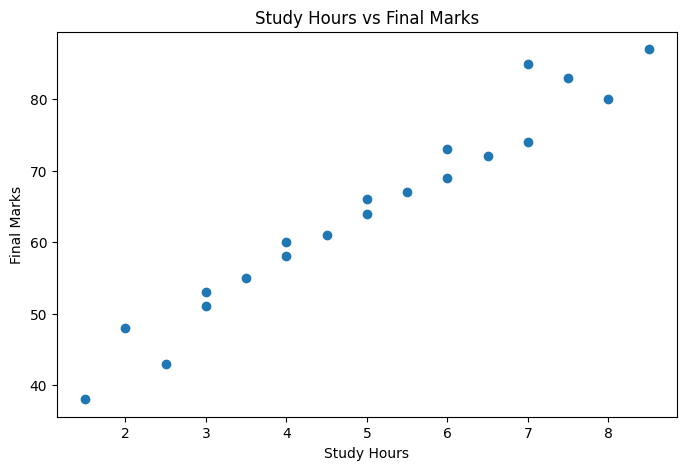

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(df["study_hours"], df["final_marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

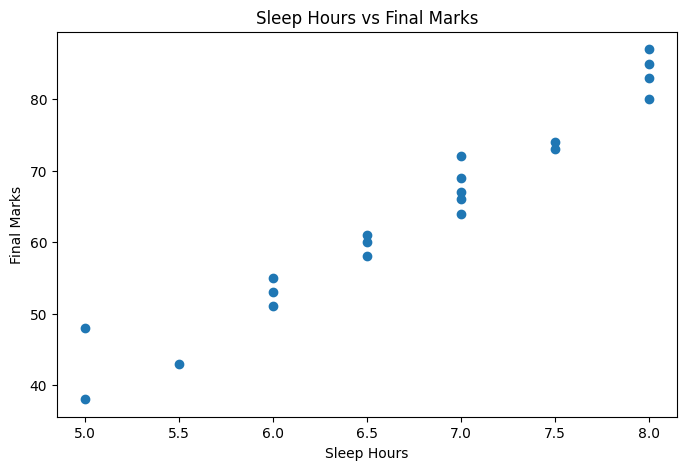

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(df["sleep_hours"], df["final_marks"])

plt.xlabel("Sleep Hours")
plt.ylabel("Final Marks")
plt.title("Sleep Hours vs Final Marks")

plt.show()

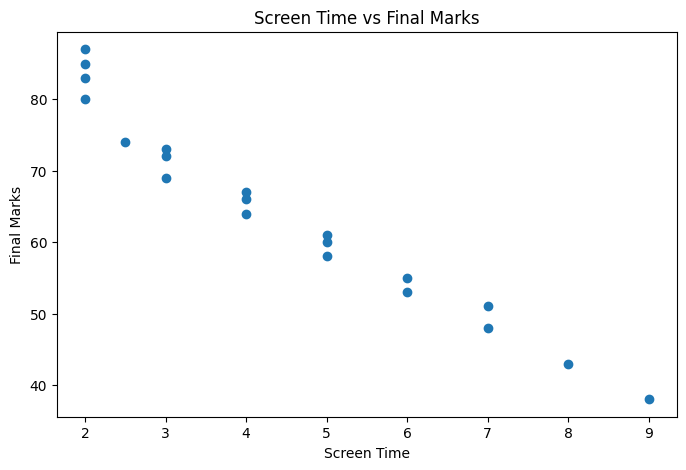

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(df["screen_time"], df["final_marks"])

plt.xlabel("Screen Time")
plt.ylabel("Final Marks")
plt.title("Screen Time vs Final Marks")

plt.show()

In [10]:
df.corr()

,study_hours,sleep_hours,screen_time,exercise_hours,attendance,previous_marks,final_marks
study_hours,1.000000,0.969087,-0.966379,0.971537,0.982080,0.976306,0.977793
sleep_hours,0.969087,1.000000,-0.966236,0.967164,0.972133,0.973769,0.974385
screen_time,-0.966379,-0.966236,1.000000,-0.966490,-0.990839,-0.980020,-0.978605
exercise_hours,0.971537,0.967164,-0.966490,1.000000,0.968714,0.968554,0.967480
attendance,0.982080,0.972133,-0.990839,0.968714,1.000000,0.991508,0.990584
previous_marks,0.976306,0.973769,-0.980020,0.968554,0.991508,1.000000,0.999706
final_marks,0.977793,0.974385,-0.978605,0.967480,0.990584,0.999706,1.000000


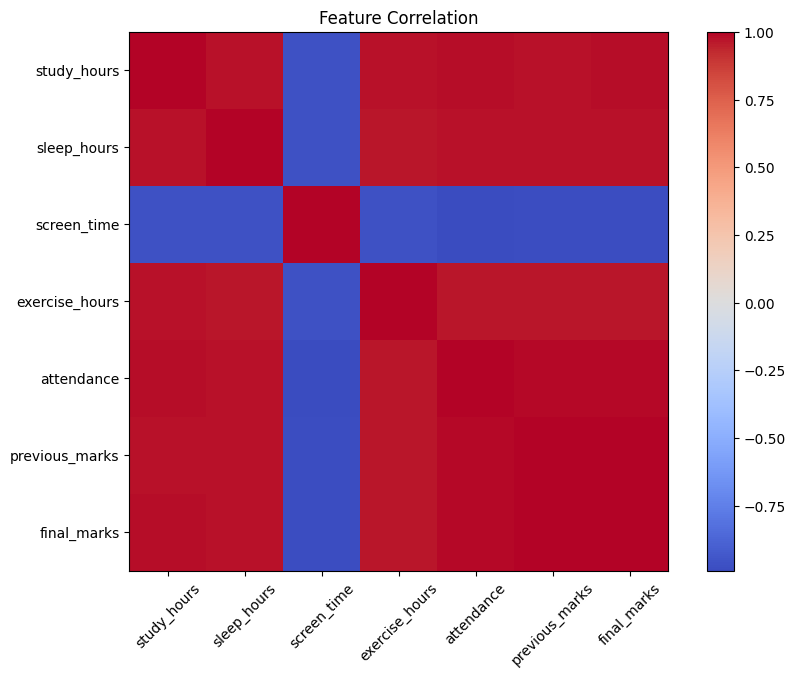

In [11]:
plt.figure(figsize=(10,7))

plt.imshow(df.corr(), cmap="coolwarm", interpolation="none")

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Feature Correlation")

plt.show()

In [12]:
X = df.drop("final_marks", axis=1)

y = df["final_marks"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

y_pred

array([47.09590192, 84.25154842, 60.09163512, 52.85213891])

In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.4730114668789991


In [17]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.3519582509569966


In [18]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9982597861510161


In [19]:
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

comparison

,Actual Marks,Predicted Marks
0,48,47.095902
1,85,84.251548
2,60,60.091635
3,53,52.852139


In [20]:
new_student = pd.DataFrame({
    "study_hours": [6],
    "sleep_hours": [7],
    "screen_time": [3],
    "exercise_hours": [1],
    "attendance": [90],
    "previous_marks": [70]
})

prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 73.77600269037065
